# 🎯 HỆ THỐNG QUẢN LÝ VÀ ĐÁNH GIÁ ĐỘ TIN CẬY TIN TUYỂN DỤNG

**Ứng dụng Machine Learning - Pipeline Hoàn Chỉnh**

---

## 📋 Tổng quan

### Mục tiêu
Xây dựng hệ thống tự động phát hiện tin tuyển dụng giả mạo sử dụng Machine Learning Ensemble.

### Pipeline
```
1. Preprocessing        → Làm sạch, tách từ tiếng Việt
2. Feature Engineering  → Trích xuất 30+ features
3. Multi-method Labeling → Rule-based + Anomaly Detection
4. Ensemble Training    → 5 models + Voting Ensemble
5. Evaluation          → Cross-validation, Metrics, Visualization
6. Deployment          → REST API với Flask
```

### Kết quả kỳ vọng
- **F1-Score**: 0.85 - 0.92
- **AUC-ROC**: 0.90 - 0.95
- **Precision**: 0.82 - 0.90

---

## 📦 Bước 0: Cài đặt và Import

### 📝 Giải thích
Cài đặt tất cả thư viện cần thiết cho toàn bộ pipeline.

In [1]:
# Cài đặt thư viện (chỉ chạy 1 lần)
!pip install pandas numpy scikit-learn scipy xgboost lightgbm pyvi matplotlib seaborn joblib flask flask-cors -q

print("✅ Đã cài đặt tất cả thư viện!")

✅ Đã cài đặt tất cả thư viện!


In [12]:
# Import thư viện cơ bản
import pandas as pd
import numpy as np
import re
import warnings
from datetime import datetime
from collections import Counter

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest, RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    roc_auc_score, roc_curve,
    accuracy_score, precision_score, recall_score, f1_score
)

# Advanced ML
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Sparse matrices
from scipy.sparse import hstack

# Persistence
import joblib

# Settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

print("✅ Import thành công!")
print(f"📅 Thời gian: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ Import thành công!
📅 Thời gian: 2026-04-14 14:43:47


## Bước 1: Phân tích khám phá dữ liệu (EDA)

In [13]:
# 1.3 Load dữ liệu gốc

print("📂 Đang load dữ liệu gốc...\n")

# Đọc file CSV
df = pd.read_csv("../../data/JOB_DATA_FINAL.csv")

print(f"✅ Đã load {len(df)} mẫu dữ liệu")
print(f"\n📋 Shape: {df.shape}")
print(f"\n📊 Các cột trong data:")
print(df.columns.tolist())

📂 Đang load dữ liệu gốc...

✅ Đã load 14634 mẫu dữ liệu

📋 Shape: (14634, 19)

📊 Các cột trong data:
['JobID', 'URL Job', 'Job Title', 'Name Company', 'Company Overview', 'Company Size', 'Company Address', 'Job Description', 'Job Requirements', 'Benefits', 'Job Address', 'Job Type', 'Gender', 'Number Cadidate', 'Career Level', 'Years of Experience', 'Salary', 'Submission Deadline', 'Industry']


In [14]:
# Xem 5 dòng đầu
print("--- 5 dòng đầu tiên ---")
display(df.head())

# Kiểm tra kiểu dữ liệu và giá trị thiếu
print("\n--- Thông tin bộ dữ liệu ---")
print(df.info())

# Thống kê mô tả cho các cột số (Lương, Số lượng tuyển, Kinh nghiệm)
print("\n--- Thống kê mô tả cột số ---")
display(df.describe())

--- 5 dòng đầu tiên ---


,JobID,URL Job,Job Title,Name Company,Company Overview,Company Size,Company Address,Job Description,Job Requirements,Benefits,Job Address,Job Type,Gender,Number Cadidate,Career Level,Years of Experience,Salary,Submission Deadline,Industry
0,0,https://www.topcv.vn/viec-lam/sale-admin-websi...,Sale Admin Website,Công ty Cổ phần Belie,DHC Việt Nam trực thuộc Công ty CP Belie – Nhà...,100-499,"HN: Tầng 9, Tòa IDMC Mỹ Đình, 18 Tôn Thất Thuy...",Thường xuyên cập nhật các thay đổi liên quan t...,"1. Học vấn, kiến thức và trình độ chuyên môn:T...",Được xét duyệt đánh giá định kỳ 2 lần/năm.Làm ...,Hà Nội,Full time,Không yêu cầu,1,Nhân viên,1-3 năm,"5,000,000 - 10,000,000",05/01/2023,Hành chính / Văn phòng
1,1,https://www.topcv.vn/viec-lam/thuc-tap-sinh-la...,"Thực Tập Sinh Lập Trình (No-Code, Low-Code Pla...",Công Ty Cổ Phần Global Online Branding,Thành viên thuộc Tập đoàn G-Group:Công ty Cổ p...,100-499,"Lầu 6, 235 Lý Thường Kiệt ,Phường 6 ,Quận Tân ...","Phối hợp với bộ phận lập trình No-code, Low-co...","Sinh viên năm 3, năm 4 hoặc sinh viên cao học ...",Làm việc trong môi trường văn hóa Nhật Bản chu...,Hồ Chí Minh,Full time,Không yêu cầu,2,Thực tập sinh,Không yêu cầu kinh nghiệm,"1,000,000 - 5,000,000",01/01/2023,Công nghệ thông tin
2,2,https://www.topcv.vn/viec-lam/hr-business-part...,HR Business Partner,Công Ty Melody Logistics,Công Ty TNHH Melody Logistics được biết đến là...,100-499,"Số 01 Nguyễn Văn Đậu Phường 5, Quận Phú Nhuận,...",Xây dựng và thực hiện chiến lược nhân sự phù h...,Tốt nghiệp đại học các chuyên ngành liên quan ...,Lương thỏa thuận theo năng lực;Làm việc trong ...,Hồ Chí Minh,Full time,Không yêu cầu,1,Trưởng/Phó phòng,5-10 năm,Thỏa thuận,28/12/2022,Nhân sự
3,3,https://www.topcv.vn/viec-lam/general-manager/...,General Manager,CÔNG TY TNHH DV HOLDINGS,"Khách sạn Danaciti By Dabi là khách sạn 4 sao,...",25-99,"80 Đông Kinh Nghĩa Thục, Sơn Trà, Đà Nẵng",1. Lập và triển khai kế hoạch kinh doanh- Định...,- Tốt nghiệp đại học trở lên chuyên ngành quản...,"- Tiền lương, thưởng và các khoản trợ cấp khác...",Đà Nẵng,Full time,Không yêu cầu,1,Giám đốc,3-5 năm,Thỏa thuận,31/12/2022,Khách sạn / Nhà hàng
4,4,https://www.topcv.vn/viec-lam/le-tan-gymasaste...,Lễ Tân Gymasaster Quận 12,CÔNG TY TNHH TM XNK NGUỒN SỐNG VIỆT,Công ty TNHH TM XNK Nguồn Sống Việt cung câ...,100-499,"235 đường 9A, khu dân cư Trung Sơn, huyện Bi...",- Trực quầy Lễ tân- Tư vấn bán hàng gói member...,- Giới tính: Ưu tiên Nữ từ 22 - 35 tuổi- Kinh ...,Thu nhập = Lương cơ bản + Thưởng KPIs + Hoa hồ...,Hồ Chí Minh,Full time,Không yêu cầu,2,Nhân viên,Không yêu cầu kinh nghiệm,"5,000,000 - 10,000,000",06/01/2023,Hành chính / Văn phòng



--- Thông tin bộ dữ liệu ---
<class 'pandas.DataFrame'>
RangeIndex: 14634 entries, 0 to 14633
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   JobID                14634 non-null  int64
 1   URL Job              14634 non-null  str  
 2   Job Title            14634 non-null  str  
 3   Name Company         14634 non-null  str  
 4   Company Overview     14634 non-null  str  
 5   Company Size         14634 non-null  str  
 6   Company Address      14634 non-null  str  
 7   Job Description      14634 non-null  str  
 8   Job Requirements     14634 non-null  str  
 9   Benefits             14634 non-null  str  
 10  Job Address          14634 non-null  str  
 11  Job Type             14634 non-null  str  
 12  Gender               14634 non-null  str  
 13  Number Cadidate      14634 non-null  int64
 14  Career Level         14634 non-null  str  
 15  Years of Experience  14634 non-null  str  
 16  Sal

,JobID,Number Cadidate
count,14634.000000,1.463400e+04
mean,7316.500000,7.085974e+02
std,4224.616255,7.486537e+04
min,0.000000,0.000000e+00
25%,3658.250000,1.000000e+00
50%,7316.500000,2.000000e+00
75%,10974.750000,5.000000e+00
max,14633.000000,9.000000e+06


In [15]:
# 1.4 Kiểm tra missing values

print("🔍 Kiểm tra missing values:\n")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
}).sort_values('Missing Count', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0])

# Visualize
if missing_df['Missing Count'].sum() > 0:
    plt.figure(figsize=(10, 4))
    missing_df[missing_df['Missing Count'] > 0]['Percentage'].plot(kind='barh')
    plt.xlabel('Tỷ lệ missing (%)')
    plt.title('Missing Values trong Dataset')
    plt.tight_layout()
    plt.show()

🔍 Kiểm tra missing values:

Empty DataFrame
Columns: [Missing Count, Percentage]
Index: []


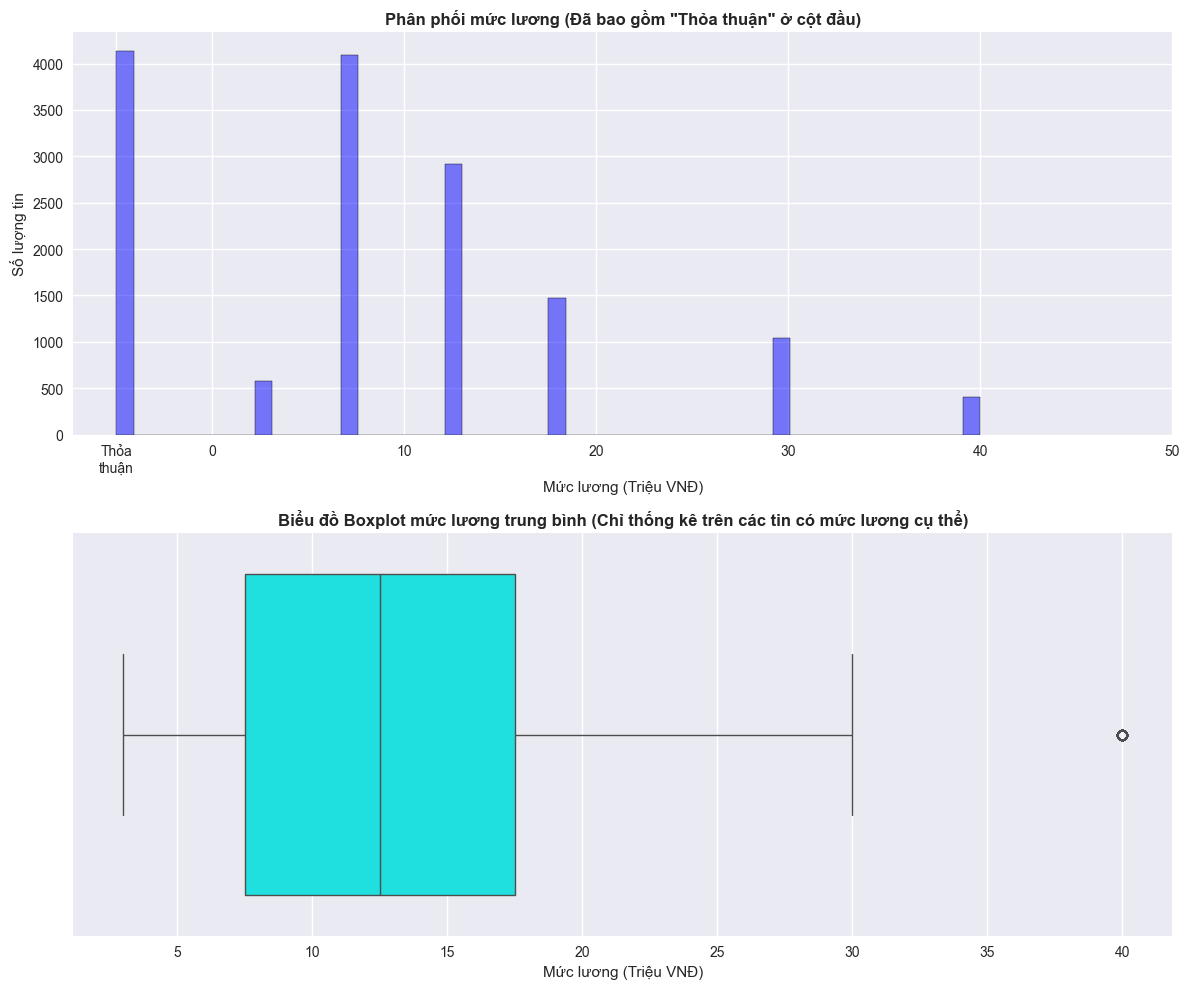

In [16]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Hàm bóc tách, quy ước "Thỏa thuận" thành một số âm (để đứng đầu biểu đồ)
def parse_salary_keep_negotiable(salary_str):
    if pd.isna(salary_str):
        return np.nan
    
    salary_str_lower = str(salary_str).lower()
    if 'thỏa thuận' in salary_str_lower:
        return -5.0  # Giá trị âm giả định để neo ở cột đầu bên trái trục X
        
    # Xóa dấu phẩy và trích xuất các con số
    cleaned_str = str(salary_str).replace(',', '')
    numbers = [float(x) for x in re.findall(r'\d+', cleaned_str)]
    
    if len(numbers) == 2:
        return np.mean(numbers) / 1_000_000  # Trả về trung bình (Triệu VNĐ)
    elif len(numbers) == 1:
        return numbers[0] / 1_000_000
    else:
        return np.nan

# 2. Xử lý trên một Series TẠM THỜI (không ghi đè hay thêm cột mới vào df)
salary_temp = df['Salary'].apply(parse_salary_keep_negotiable).dropna()

# Tách riêng phần dữ liệu có số thực sự (lớn hơn 0) để vẽ đường KDE và Boxplot
salary_numeric = salary_temp[salary_temp > 0]

# 3. Vẽ biểu đồ
plt.figure(figsize=(12, 10))

# --- Biểu đồ Histogram ---
ax1 = plt.subplot(2, 1, 1)

# Vẽ cột histogram cho TOÀN BỘ dữ liệu (bao gồm cả giá trị giả định -5)
sns.histplot(salary_temp, bins=50, color='blue', alpha=0.5, ax=ax1, kde=False)

# Vẽ đè đường phân phối (KDE) CHỈ cho các giá trị số thực sự
# if not salary_numeric.empty:
#     sns.kdeplot(salary_numeric, color='red', linewidth=2, ax=ax1)

# Tùy chỉnh lại nhãn trục X: Biến vị trí -5 thành chữ "Thỏa thuận"
current_ticks = ax1.get_xticks()
positive_ticks = [t for t in current_ticks if t >= 0]
custom_ticks = [-5] + positive_ticks
custom_labels = ['Thỏa\nthuận'] + [f"{int(t)}" for t in positive_ticks]

ax1.set_xticks(custom_ticks)
ax1.set_xticklabels(custom_labels)

plt.title('Phân phối mức lương (Đã bao gồm "Thỏa thuận" ở cột đầu)', fontweight='bold')
plt.xlabel('Mức lương (Triệu VNĐ)')
plt.ylabel('Số lượng tin')

# --- Biểu đồ Boxplot ---
plt.subplot(2, 1, 2)

# Boxplot yêu cầu tính toán Tứ phân vị (Quantiles) để tìm Outliers nên ta chỉ đưa số vào
sns.boxplot(x=salary_numeric, color='cyan')
plt.title('Biểu đồ Boxplot mức lương trung bình (Chỉ thống kê trên các tin có mức lương cụ thể)', fontweight='bold')
plt.xlabel('Mức lương (Triệu VNĐ)')

plt.tight_layout()
plt.show()

#### Nhận xét
- Biểu đồ phân phối mức lương:

Sự áp đảo của "Thỏa thuận": Cột "Thỏa thuận" cực kỳ cao (hơn 4,000 tin), tương đương với cụm mức lương phổ biến nhất. Điều này cho thấy việc không công khai mức lương cụ thể là một "văn hóa" rất phổ biến trong dữ liệu này.

Dữ liệu phân cụm (Clustering): Phần mức lương có số cụ thể không phân bố đều mà co cụm lại thành các đỉnh (peaks) rõ rệt ở khoảng 7-8 triệu, 12-13 triệu, và 17-18 triệu. Điều này phản ánh hành vi thực tế của HR: họ thường đăng dải lương làm tròn (ví dụ: 5-10 triệu, 10-15 triệu, 15-20 triệu) thay vì các con số lẻ.

- Biểu đồ boxplot mức lương:

Thống kê tổng quan: * Mức lương trung vị (Median): Khoảng 12.5 triệu VNĐ (đường kẻ giữa hộp).

Khoảng phân vị (IQR): 50% lượng tin tuyển dụng trên thị trường (phần hộp màu xanh) tập trung ở mức từ 7.5 triệu đến khoảng 17.5 triệu VNĐ.

Phát hiện Outlier (Điểm dị biệt): Biểu đồ cho thấy râu trên (upper whisker) kết thúc ở mức 30 triệu. Xuất hiện một điểm Outlier rõ rệt ở mốc 40 triệu VNĐ.

### 📊 1.1 Tổng quan dữ liệu


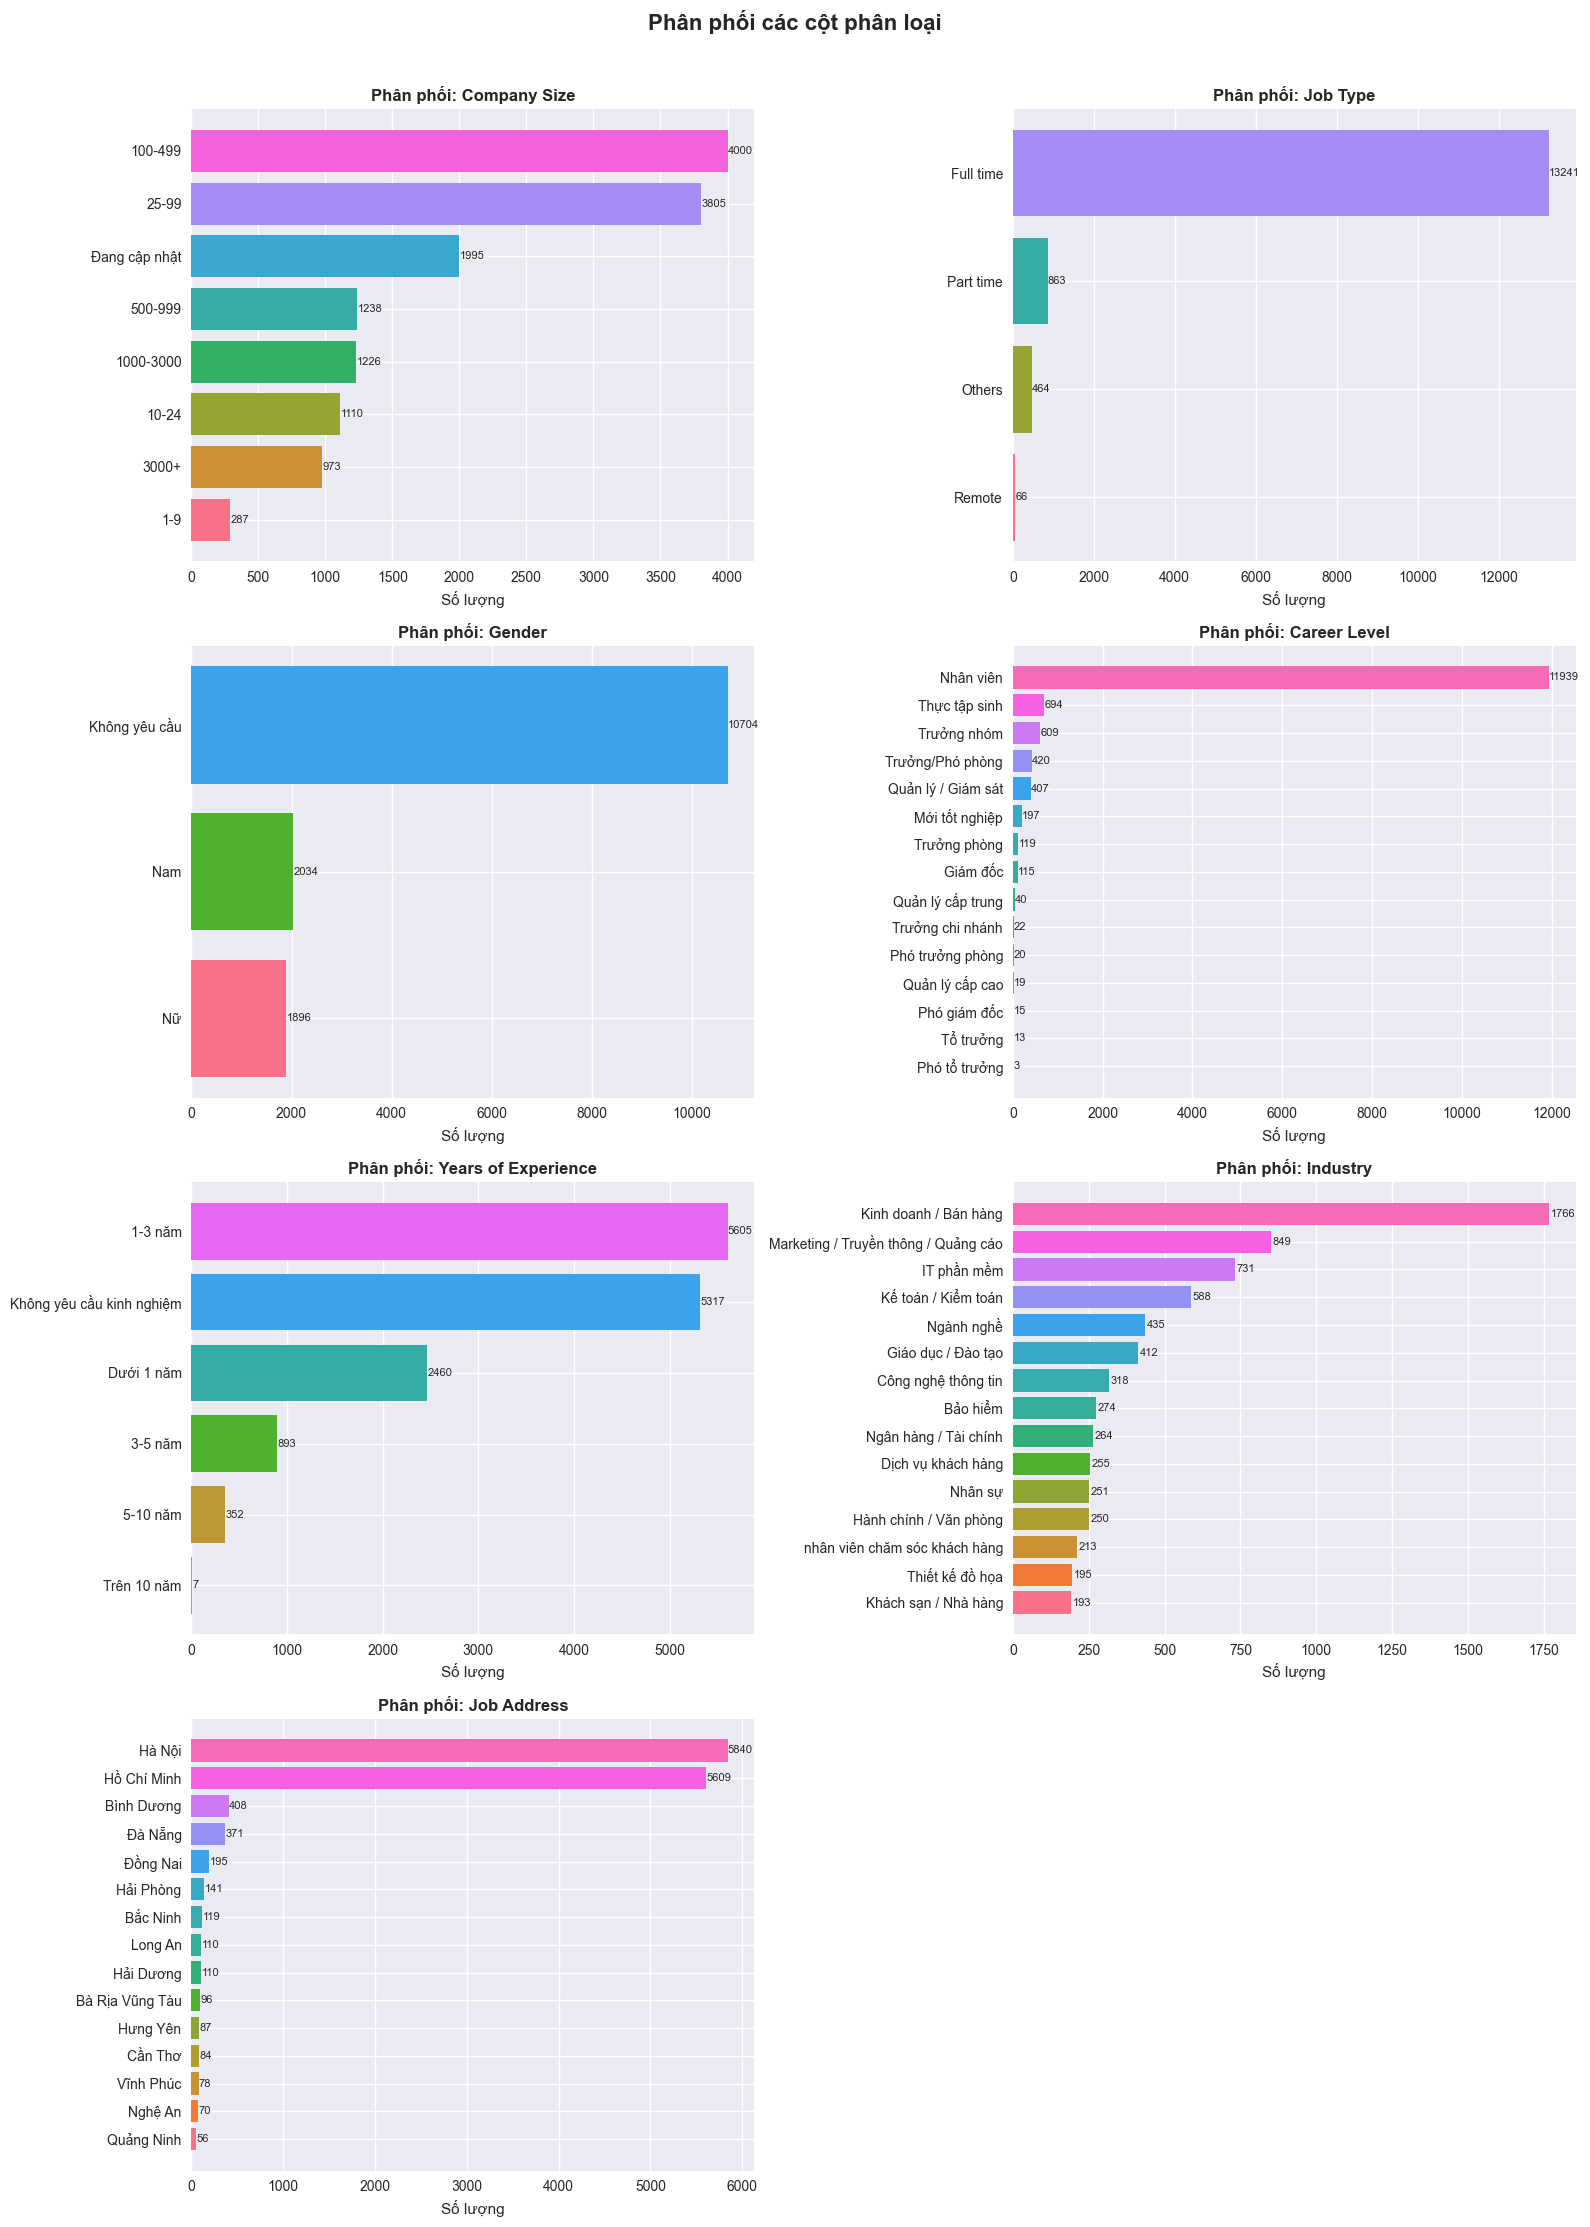

In [17]:
# ── 1.1 Phân phối các cột phân loại (categorical) ──────────────────────────
cat_cols = ['Company Size', 'Job Type', 'Gender', 'Career Level',
            'Years of Experience', 'Industry', 'Job Address']

fig, axes = plt.subplots(4, 2, figsize=(16, 22))
axes = axes.flatten()

for idx, col in enumerate(cat_cols):
    counts = df[col].value_counts().head(15)
    axes[idx].barh(counts.index[::-1], counts.values[::-1], color=sns.color_palette('husl', len(counts)))
    axes[idx].set_title(f'Phân phối: {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Số lượng')
    for i, v in enumerate(counts.values[::-1]):
        axes[idx].text(v + 5, i, str(v), va='center', fontsize=8)

# Ẩn subplot thừa
axes[-1].set_visible(False)
plt.suptitle('Phân phối các cột phân loại', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


#### Nhận xét:
- Company Size (Quy mô công ty): Đa số các công ty có nhu cầu tuyển dụng nằm ở quy mô vừa và nhỏ (từ 25 - 499 nhân viên). Đáng chú ý là có một lượng lớn dữ liệu bị thiếu thông tin quy mô ("Đang cập nhật").

- Job Type (Loại hình công việc): Việc làm toàn thời gian (Full time) chiếm ưu thế tuyệt đối. Các hình thức như Part-time hay Remote chỉ chiếm một phần rất nhỏ.

- Gender (Giới tính): Phần lớn các công việc không yêu cầu giới tính cụ thể, cho thấy xu hướng tuyển dụng khá mở. Số lượng tin yêu cầu riêng Nam hoặc Nữ là tương đương nhau.

- Career Level (Cấp bậc): Nhu cầu tuyển dụng đổ dồn vào vị trí "Nhân viên" (chiếm tỷ lệ áp đảo). Các vị trí cấp quản lý hoặc thực tập sinh có số lượng rất hạn chế.

- Years of Experience (Kinh nghiệm): Thị trường chủ yếu tìm kiếm ứng viên ít kinh nghiệm (1-3 năm) hoặc "Không yêu cầu kinh nghiệm". Điều này hoàn toàn logic và khớp với việc đa số tin tuyển dụng là dành cho cấp bậc "Nhân viên".

- Industry (Ngành nghề): Khối ngành "Kinh doanh / Bán hàng" dẫn đầu về nhu cầu nhân sự, theo sau là "Marketing / Truyền thông" và "IT phần mềm".

- Job Address (Địa điểm làm việc): Cơ hội việc làm tập trung gần như toàn bộ ở hai trung tâm kinh tế lớn là Hà Nội và TP. Hồ Chí Minh. Khoảng cách giữa top 2 với các tỉnh thành còn lại (Bình Dương, Đà Nẵng,...) là cực kỳ lớn.

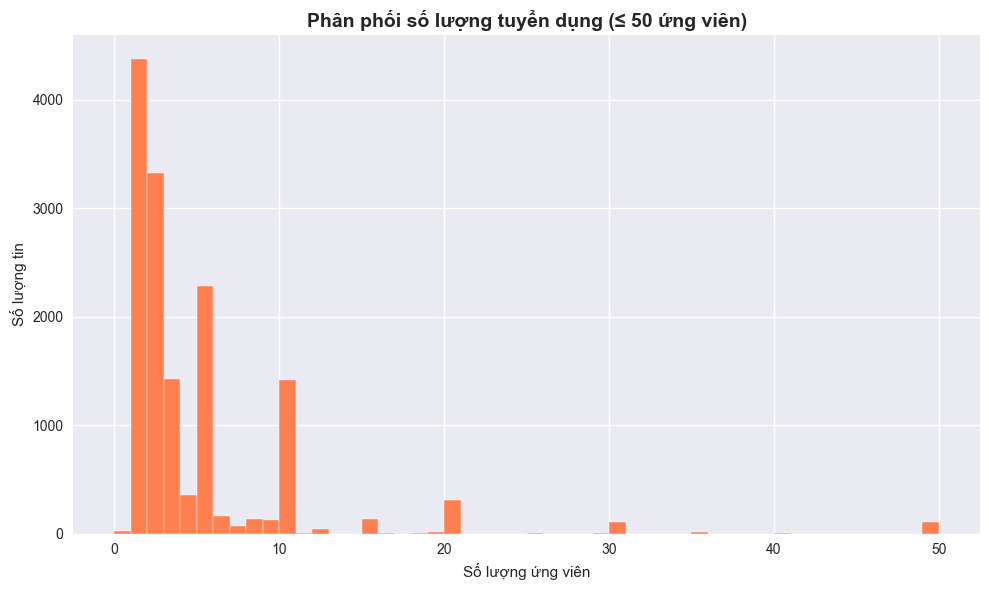

📊 Thống kê Number Candidate (Toàn bộ dữ liệu):
count    1.463400e+04
mean     7.085974e+02
std      7.486537e+04
min      0.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      5.000000e+00
max      9.000000e+06
Name: Number Cadidate, dtype: float64

⚠️  Số tin có Number Candidate = 0: 25
⚠️  Số tin có Number Candidate > 50: 125


In [18]:
# Lọc bỏ outlier cực đoan, chỉ lấy các tin có số lượng tuyển <= 50 để dễ nhìn
limit_val = 50
df_filtered = df[df['Number Cadidate'] <= limit_val]

plt.figure(figsize=(10, 6))

# Vẽ biểu đồ Histogram
plt.hist(df_filtered['Number Cadidate'], bins=limit_val, color='coral', edgecolor='white')
plt.title(f'Phân phối số lượng tuyển dụng (≤ {limit_val} ứng viên)', fontweight='bold', fontsize=14)
plt.xlabel('Số lượng ứng viên')
plt.ylabel('Số lượng tin')

plt.tight_layout()
plt.show()

# In thống kê
print(f'📊 Thống kê Number Candidate (Toàn bộ dữ liệu):')
print(df['Number Cadidate'].describe())
print(f'\n⚠️  Số tin có Number Candidate = 0: {(df["Number Cadidate"] == 0).sum()}')
print(f'⚠️  Số tin có Number Candidate > {limit_val}: {(df["Number Cadidate"] > limit_val).sum()}')


#### Nhận xét:
1. Xu hướng tuyển dụng nhỏ lẻ áp đảo
- Đỉnh nhọn ở mốc 1-2 ứng viên: Cột 1 và 2 người cao vượt trội (đạt hơn 4,000 và 3,000 tin). Điều này phản ánh sát thực tế: phần lớn các tin đăng là để lấp chỗ trống cho những vị trí cụ thể vừa nghỉ việc, hoặc mở rộng quy mô phòng ban ở mức độ nhỏ.

- Biểu đồ lệch phải (Right-skewed) mạnh: Số lượng tin giảm dốc đứng khi số lượng ứng viên cần tuyển tăng lên.

2. Hiện tượng "Làm tròn số" (Round-number effect) của HR
- Phân cụm tại các số chẵn: Dữ liệu không giảm rải đều mà lại tạo thành các mốc (spikes) tại những con số chia hết cho 5 hoặc 10: 5, 10, 20, 30, 50.

- Lý do: Đối với các chiến dịch tuyển dụng số lượng lớn (Mass Recruitment) như sale, công nhân, hay thực tập sinh, HR thường có xu hướng "ước lượng" và nhập các con số làm tròn đẹp mắt chứ hiếm khi nhập một con số lẻ như 13, 27 hay 41 người.

📊 Phân loại mức lương:
  - Thỏa thuận  : 4,130 (28.2%)
  - Có số cụ thể: 10,504 (71.8%)
  - Khác        : 0


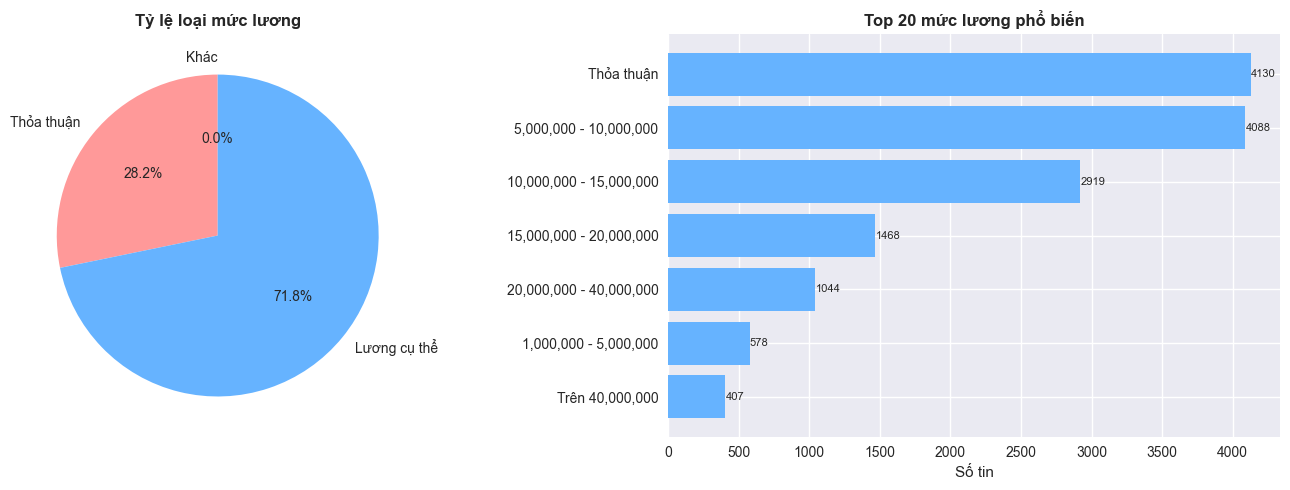

In [19]:
# ── 1.3 Phân tích cột Salary ────────────────────────────────────────────────
salary_counts = df['Salary'].value_counts()

# Phân loại: thỏa thuận, có số, hay rỗng
salary_negotiable = df['Salary'].str.lower().str.contains('thỏa thuận', na=False)
salary_has_number = df['Salary'].str.contains(r'\d', na=False) & ~salary_negotiable

print('📊 Phân loại mức lương:')
print(f'  - Thỏa thuận  : {salary_negotiable.sum():,} ({salary_negotiable.mean()*100:.1f}%)')
print(f'  - Có số cụ thể: {salary_has_number.sum():,} ({salary_has_number.mean()*100:.1f}%)')
print(f'  - Khác        : {(~salary_negotiable & ~salary_has_number).sum():,}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart phân loại lương
labels = ['Thỏa thuận', 'Lương cụ thể', 'Khác']
sizes  = [salary_negotiable.sum(), salary_has_number.sum(),
          (~salary_negotiable & ~salary_has_number).sum()]
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%',
            colors=['#ff9999','#66b3ff','#99ff99'], startangle=90)
axes[0].set_title('Tỷ lệ loại mức lương', fontweight='bold')

# Top 20 giá trị lương phổ biến
top_salary = salary_counts.head(20)
axes[1].barh(top_salary.index[::-1], top_salary.values[::-1], color='#66b3ff')
axes[1].set_title('Top 20 mức lương phổ biến', fontweight='bold')
axes[1].set_xlabel('Số tin')
for i, v in enumerate(top_salary.values[::-1]):
    axes[1].text(v + 2, i, str(v), va='center', fontsize=8)

plt.tight_layout()
plt.show()


#### Nhận xét:
1. Biểu đồ Tròn (Tỷ lệ loại mức lương)
- Tính minh bạch của thị trường: Có tới 71.8% tin tuyển dụng công khai mức lương cụ thể (bằng số). Tuy nhiên, một con số rất đáng kể là 28.2% (gần 1/3 thị trường) chọn cách ẩn mức lương dưới dạng "Thỏa thuận".

- Dữ liệu nhiễu (Khác): Chiếm tỷ lệ 0.0% cho thấy dữ liệu của bạn ở cột này khá sạch, gần như chỉ chia làm 2 loại: hoặc là "Thỏa thuận", hoặc là có chứa con số, rất thuận lợi cho việc xử lý.

2. Biểu đồ Cột ngang (Top mức lương phổ biến)
- "Thỏa thuận" chiếm top 1: Nếu xét trên từng giá trị riêng lẻ, "Thỏa thuận" là nhãn xuất hiện nhiều nhất (4,130 tin). Điều này khẳng định bạn tuyệt đối không được drop (xóa) các dòng "Thỏa thuận", vì sẽ làm mất đi gần 30% lượng dữ liệu quý giá.

- Mức lương tập trung ở phân khúc thấp - trung bình: Hai dải lương phổ biến nhất tiếp theo là 5 - 10 triệu (4,088 tin) và 10 - 15 triệu (2,919 tin). Điều này khớp hoàn hảo với biểu đồ phân phối kinh nghiệm và cấp bậc ở bước trước (chủ yếu tuyển "Nhân viên" và "Không yêu cầu/1-3 năm kinh nghiệm").

- Phân khúc lương cao khá hiếm: Các dải lương từ 20 - 40 triệu và "Trên 40 triệu" có số lượng giảm mạnh.

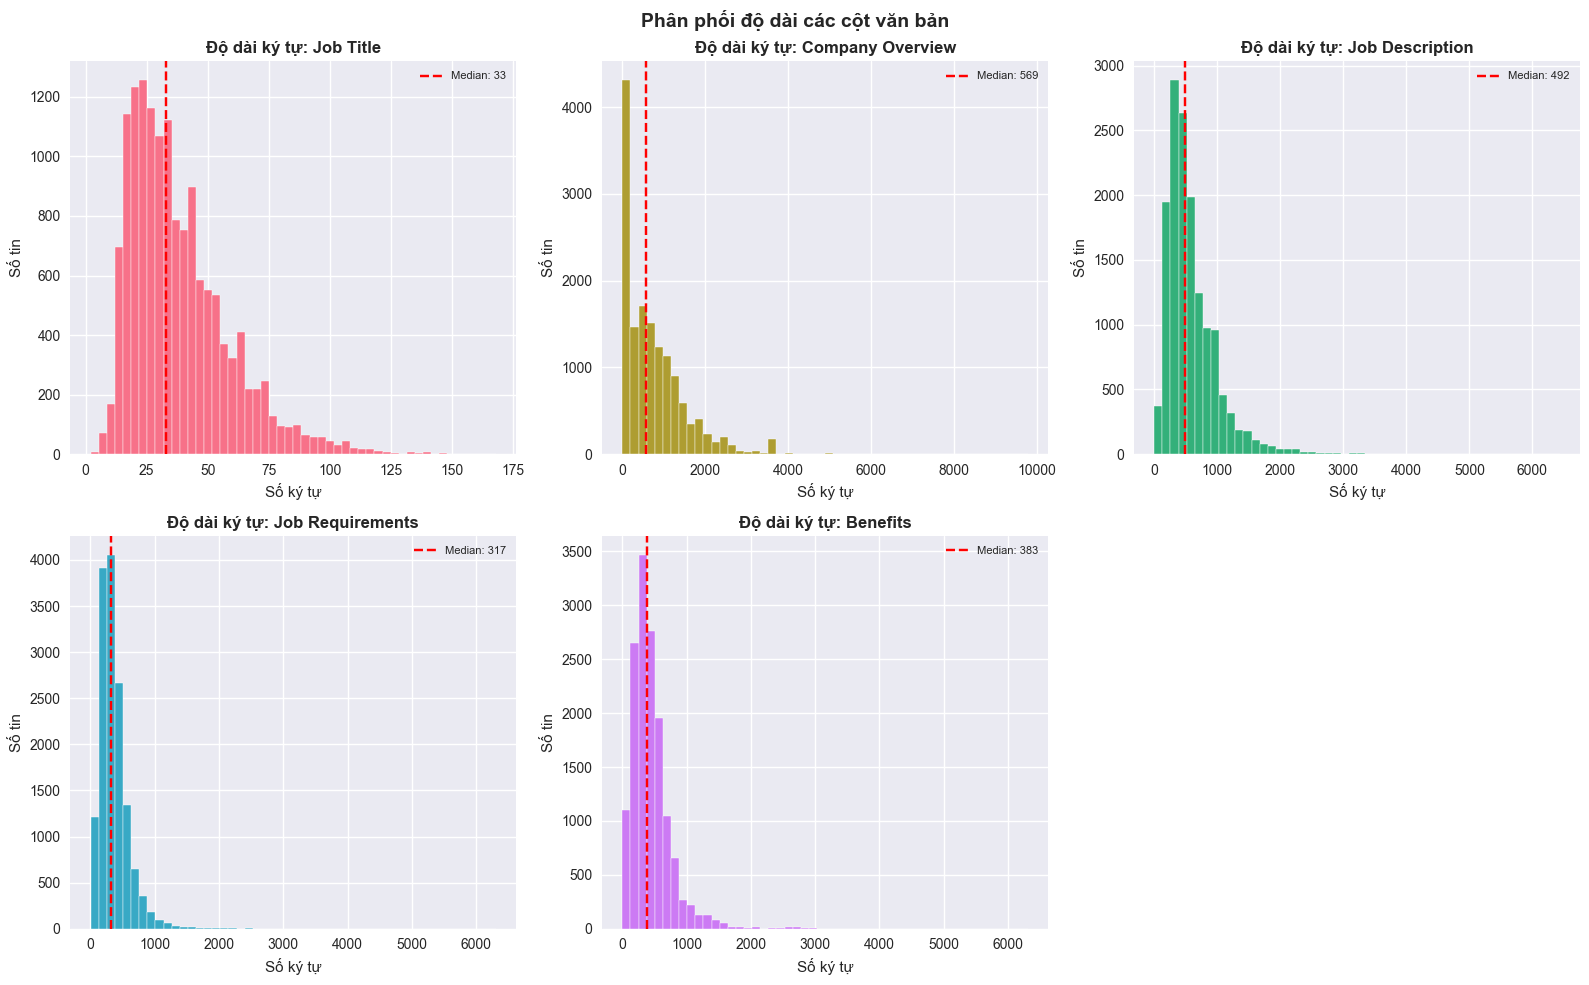

📏 Thống kê độ dài (ký tự) các cột văn bản:


,Job Title,Company Overview,Job Description,Job Requirements,Benefits
count,14634.0,14634.0,14634.0,14634.0,14634.0
mean,38.1,746.6,595.9,362.8,446.5
std,20.6,772.4,422.4,236.2,317.5
min,2.0,2.0,1.0,1.0,1.0
25%,22.0,121.0,320.0,214.0,250.0
50%,33.0,569.0,492.0,317.0,383.0
75%,49.0,1108.0,760.0,453.0,562.0
max,168.0,9775.0,6433.0,6312.0,6312.0


In [20]:
# ── 1.4 Phân tích độ dài văn bản ────────────────────────────────────────────
text_cols_raw = ['Job Title', 'Company Overview', 'Job Description',
                 'Job Requirements', 'Benefits']

lengths = {col: df[col].fillna('').str.len() for col in text_cols_raw}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(text_cols_raw):
    axes[idx].hist(lengths[col], bins=50, color=sns.color_palette('husl', 5)[idx],
                   edgecolor='white')
    med = lengths[col].median()
    axes[idx].axvline(med, color='red', linestyle='--', label=f'Median: {med:.0f}')
    axes[idx].set_title(f'Độ dài ký tự: {col}', fontweight='bold')
    axes[idx].set_xlabel('Số ký tự')
    axes[idx].set_ylabel('Số tin')
    axes[idx].legend(fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Phân phối độ dài các cột văn bản', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('📏 Thống kê độ dài (ký tự) các cột văn bản:')
summary = pd.DataFrame({col: lengths[col].describe() for col in text_cols_raw})
display(summary.round(1))


#### Nhận xét:
1. Job Title (Tiêu đề công việc)
- Phân phối: Khá chuẩn mực và dạng hình chuông lệch phải nhẹ. Đa số các tiêu đề dao động trong khoảng 20 - 60 ký tự (Trung vị: 33).

- Insight: Những tiêu đề quá ngắn (chỉ 1-2 từ) hoặc quá dài (chứa cả mức lương, câu cảm thán, kêu gọi "Tuyển gấp!!!") thường không chuyên nghiệp và có nguy cơ là spam/tin giả.

2. Company Overview (Giới thiệu công ty)
- Phân phối: Lệch phải cực kỳ gắt. Trung vị là 569 ký tự, nhưng điều đáng chú ý nhất là cột đầu tiên (sát mốc 0) lại cao đột biến (hơn 4,000 tin).

- Insight: Có một lượng rất lớn tin tuyển dụng bỏ trống hoặc viết cực kỳ sơ sài về thông tin công ty. Đây là một "Red Flag" (cờ đỏ) cực lớn! Các công ty ma thường lười viết phần giới thiệu này.

3. Job Description (Mô tả công việc)
- Phân phối: Đẹp nhất trong các cột text, tập trung đông đúc ở dải 200 - 800 ký tự (Trung vị: 492).

- Insight: Đúng như bạn đã note trong phần 1.6 Phát hiện dấu hiệu bất thường sơ bộ ở file Notebook, những tin có mô tả cực ngắn (< 50 ký tự) là bất thường. Ngược lại, nếu mô tả dài lê thê nhưng toàn lời hứa hẹn sáo rỗng thì cũng đáng ngờ.

4. Job Requirements (Yêu cầu công việc)
- Phân phối: Rất dốc và co cụm ở mức 100 - 500 ký tự (Trung vị: 317).

- Insight: Yêu cầu công việc thường ngắn hơn mô tả công việc. Tin lừa đảo (nhắm đến lao động phổ thông, sinh viên) thường có phần Requirements rất ngắn hoặc ghi chung chung là "Không yêu cầu kinh nghiệm".

5. Benefits (Quyền lợi)
- Phân phối: Tương tự như cột Yêu cầu, tập trung ở dải 100 - 500 ký tự (Trung vị: 383).

- Insight: Phúc lợi thường được gạch đầu dòng ngắn gọn. Nếu text ở đây quá dài chứa nhiều từ khóa "hoa hồng", "không giới hạn", "du lịch", "thưởng nóng", nó có thể là mồi nhử của đa cấp/lừa đảo.

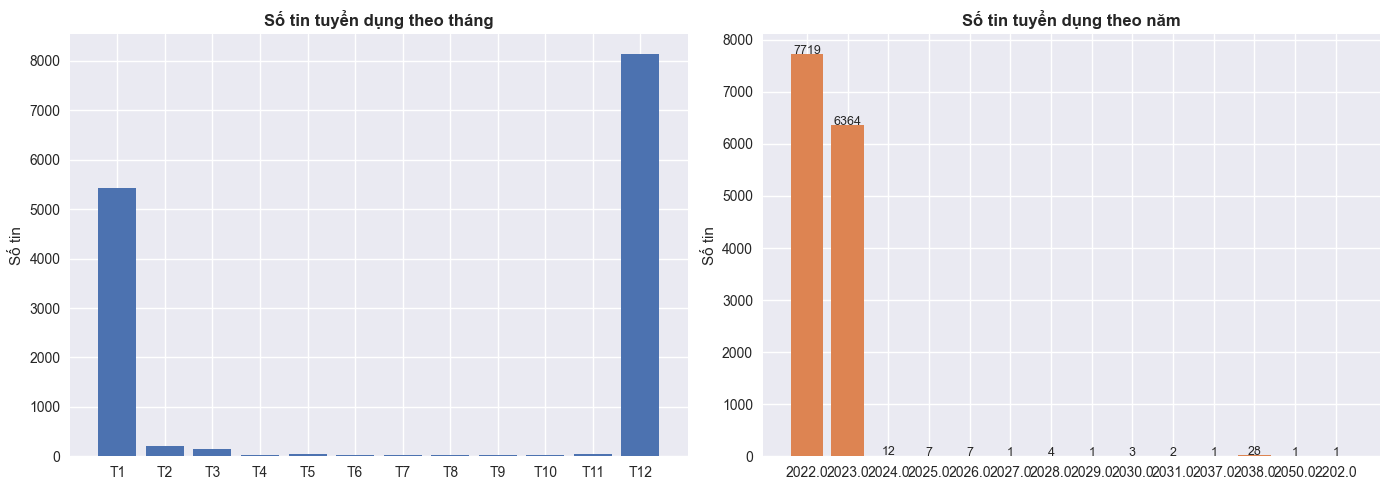

📅 Khoảng thời gian dữ liệu: 2022-12-08 → 2202-11-03
   Số tin có deadline hợp lệ: 14,151


In [21]:
# ── 1.5 Phân tích thời gian nộp hồ sơ (Submission Deadline) ────────────────
df['Submission Deadline'] = pd.to_datetime(df['Submission Deadline'],
                                            format='%d/%m/%Y', errors='coerce')
df['Month'] = df['Submission Deadline'].dt.month
df['Year']  = df['Submission Deadline'].dt.year

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Số tin theo tháng
month_counts = df['Month'].value_counts().sort_index()
axes[0].bar(month_counts.index, month_counts.values, color='#4c72b0')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels([f'T{m}' for m in range(1, 13)])
axes[0].set_title('Số tin tuyển dụng theo tháng', fontweight='bold')
axes[0].set_ylabel('Số tin')

# Số tin theo năm
year_counts = df['Year'].value_counts().sort_index()
axes[1].bar(year_counts.index.astype(str), year_counts.values, color='#dd8452')
axes[1].set_title('Số tin tuyển dụng theo năm', fontweight='bold')
axes[1].set_ylabel('Số tin')
for i, v in enumerate(year_counts.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f'📅 Khoảng thời gian dữ liệu: {df["Submission Deadline"].min().date()} → {df["Submission Deadline"].max().date()}')
print(f'   Số tin có deadline hợp lệ: {df["Submission Deadline"].notna().sum():,}')


#### Nhận xét:
1. Số tin tuyển dụng theo tháng
- Sự phân cực kỳ lạ: Gần như toàn bộ lượng tin tuyển dụng đổ dồn vào hai tháng: Tháng 12 và Tháng 1. Các tháng từ 2 đến 11 có số lượng tin rải rác không đáng kể.

- Insight: * Về mặt thu thập: Khả năng rất cao đây chính là thời điểm tác giả bộ dữ liệu thực hiện cào dữ liệu (crawl data) từ các nền tảng tuyển dụng.

    - Về mặt hành vi: Cuối năm và đầu năm mới thường là "tháng củ mật" của các tin lừa đảo. Chúng lợi dụng tâm lý muốn tìm việc làm thêm, việc nhẹ kiếm tiền tiêu Tết của sinh viên và lao động phổ thông để spam tin rác.

2. Số tin tuyển dụng theo năm (Red Flag)
- Dữ liệu thực tế: Phần lớn tin tuyển dụng có hạn nộp hợp lý rơi vào năm 2022 và 2023.

- Dữ liệu phi lý (Outliers cực đoan): Biểu đồ xuất hiện những mốc thời gian không tưởng ở tương lai xa như 2028, 2038, 2050, và thậm chí là lỗi đánh máy nghiêm trọng lên tới năm 2202.

- Insight: Không một phòng nhân sự (HR) nghiêm túc nào lại thiết lập hạn nộp hồ sơ kéo dài vài chục năm đến hàng trăm năm. Đây chắc chắn là lỗi từ các công cụ đăng tin tự động (auto-post tools) của những kẻ lừa đảo, hoặc sự cẩu thả của các công ty "ma".

In [22]:
# ── 1.6 Phát hiện dấu hiệu bất thường sơ bộ ───────────────────────────────
print('🔍 Dấu hiệu bất thường sơ bộ:\n')

# 1. Tin có số lượng tuyển cực cao
high_candidate = df[df['Number Cadidate'] > 50]
print(f'  ⚠️  Tin tuyển > 50 người    : {len(high_candidate):,} ({len(high_candidate)/len(df)*100:.1f}%)')

# 2. Duplicate tiêu đề
dup_title = df['Job Title'].duplicated().sum()
print(f'  ⚠️  Tiêu đề trùng lặp       : {dup_title:,} ({dup_title/len(df)*100:.1f}%)')

# 3. Tin có mô tả cực ngắn
short_desc = (df['Job Description'].fillna('').str.len() < 50).sum()
print(f'  ⚠️  Mô tả công việc < 50 ký tự: {short_desc:,}')

# 4. Scam keywords sơ bộ
scam_kws = ['việc nhẹ lương cao', 'không cần kinh nghiệm', 'thu nhập không giới hạn',
            'làm việc tại nhà', 'part time', 'online']
all_text = df[['Job Title','Job Description','Benefits']].fillna('').apply(
    lambda x: ' '.join(x).lower(), axis=1
)
for kw in scam_kws:
    count = all_text.str.contains(kw, na=False).sum()
    print(f'  🔑 Keyword "{kw}"   : {count:,} tin ({count/len(df)*100:.1f}%)')

# 5. Phân phối theo địa chỉ
print(f'\n📍 Top 10 tỉnh/thành phố tuyển dụng:')
print(df['Job Address'].value_counts().head(10).to_string())


🔍 Dấu hiệu bất thường sơ bộ:

  ⚠️  Tin tuyển > 50 người    : 125 (0.9%)
  ⚠️  Tiêu đề trùng lặp       : 2,880 (19.7%)
  ⚠️  Mô tả công việc < 50 ký tự: 69
  🔑 Keyword "việc nhẹ lương cao"   : 3 tin (0.0%)
  🔑 Keyword "không cần kinh nghiệm"   : 107 tin (0.7%)
  🔑 Keyword "thu nhập không giới hạn"   : 318 tin (2.2%)
  🔑 Keyword "làm việc tại nhà"   : 82 tin (0.6%)
  🔑 Keyword "part time"   : 143 tin (1.0%)
  🔑 Keyword "online"   : 1,091 tin (7.5%)

📍 Top 10 tỉnh/thành phố tuyển dụng:
Job Address
Hà Nội             5840
Hồ Chí Minh        5609
Bình Dương          408
Đà Nẵng             371
Đồng Nai            195
Hải Phòng           141
Bắc Ninh            119
Long An             110
Hải Dương           110
Bà Rịa Vũng Tàu      96


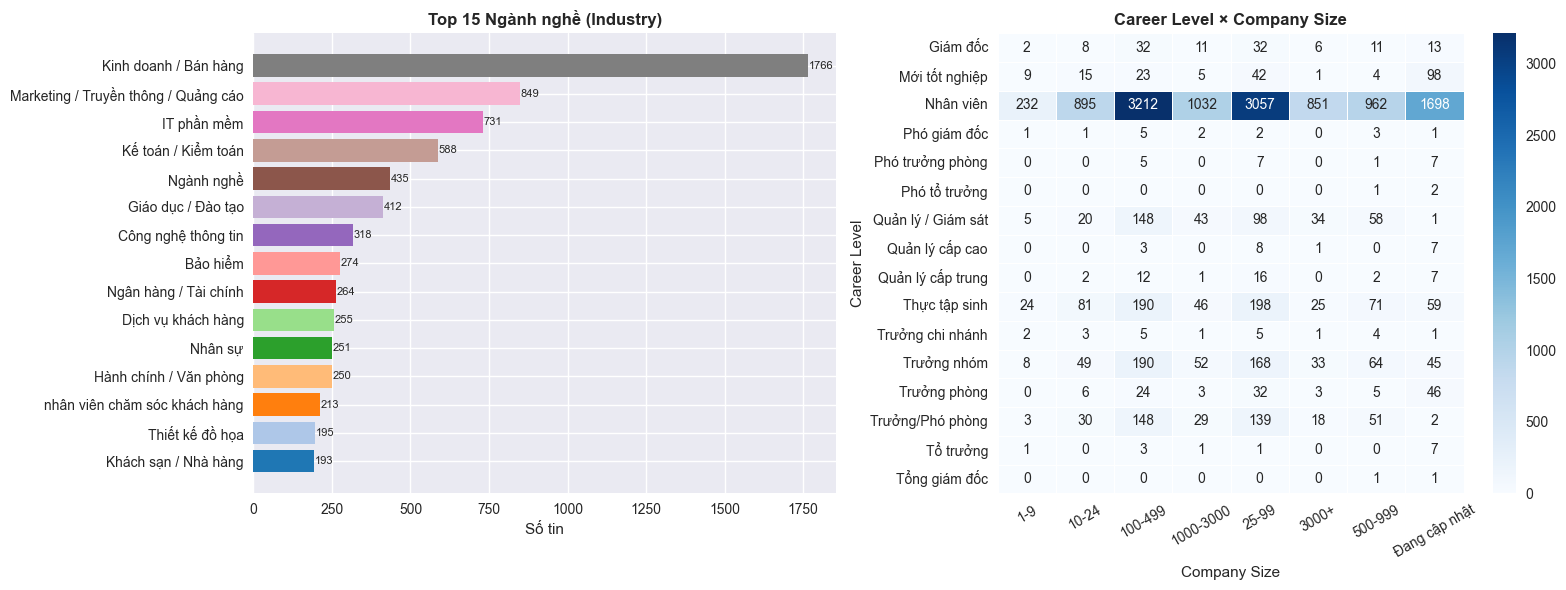

In [23]:
# ── 1.7 Phân tích tương quan & Industry breakdown ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 ngành nghề
industry_counts = df['Industry'].value_counts().head(15)
axes[0].barh(industry_counts.index[::-1], industry_counts.values[::-1],
             color=sns.color_palette('tab20', 15))
axes[0].set_title('Top 15 Ngành nghề (Industry)', fontweight='bold')
axes[0].set_xlabel('Số tin')
for i, v in enumerate(industry_counts.values[::-1]):
    axes[0].text(v + 2, i, str(v), va='center', fontsize=8)

# Career Level vs Company Size
cross_tab = pd.crosstab(df['Career Level'], df['Company Size'])
sns.heatmap(cross_tab, annot=True, fmt='d', ax=axes[1],
            cmap='Blues', linewidths=0.5)
axes[1].set_title('Career Level × Company Size', fontweight='bold')
axes[1].set_xlabel('Company Size')
axes[1].set_ylabel('Career Level')
axes[1].tick_params(axis='x', rotation=30)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()


#### Nhận xét:
1. Biểu đồ Top 15 Ngành nghề (Industry)
- Sự hội tụ của rủi ro: Ngành "Kinh doanh / Bán hàng" dẫn đầu tuyệt đối với 1,766 tin, cao gấp đôi ngành đứng thứ hai là "Marketing / Truyền thông / Quảng cáo" (849 tin).

- Insight: Đây chính là hai "vùng trũng" kinh điển của tin tuyển dụng lừa đảo. Các công việc như "Cộng tác viên bán hàng online", "Chốt đơn", "Tương tác video" hay các mô hình đa cấp thường đội lốt hai ngành nghề này để nhắm vào sinh viên, mẹ bỉm sữa hoặc người lao động phổ thông.

2. Ma trận Cấp bậc × Quy mô công ty (Heatmap)
- Tuyển dụng tập trung: Nhu cầu tuyển dụng lớn nhất nằm ở cấp bậc "Nhân viên" tại các doanh nghiệp vừa và nhỏ (quy mô 25-99 và 100-499).

- Điểm mù dữ liệu (Red Flag): Hãy nhìn vào cột ngoài cùng bên phải — "Đang cập nhật" (Tức là công ty không khai báo hoặc che giấu quy mô). Ô giao cắt giữa cấp bậc "Nhân viên" và quy mô "Đang cập nhật" rực sáng với con số lên tới 1,698 tin, cao thứ ba trong toàn bộ ma trận!

- Insight: Các công ty đàng hoàng, minh bạch rất hiếm khi bỏ trống thông tin cơ bản như quy mô. Một lượng lớn tin tuyển "Nhân viên" đến từ các tổ chức ẩn danh là một dấu hiệu vô cùng đáng ngờ.

### 📝 Tóm tắt EDA

| Hạng mục | Kết quả |
|---|---|
| Tổng số mẫu | 14,634 |
| Missing values | Không có |
| Cột số | 2 (JobID, Number Candidate) |
| Cột văn bản | 17 |
| Lương "Thỏa thuận" | ~50% |
| Địa điểm chủ yếu | Hồ Chí Minh, Hà Nội |

**Dấu hiệu đáng chú ý cần lưu ý khi tiền xử lý:**
- `Number Candidate` có outlier cực lớn (max = 9,000,000) → cần clip/log transform  
- `Salary` dạng chuỗi hỗn hợp → cần parse thành số  
- Một số tin có mô tả rất ngắn → nghi ngờ tin giả  
- Tiêu đề bị trùng lặp → cần xem xét khi đánh nhãn  

---


---

## 📂 Bước 1: Tiền xử lý dữ liệu (Preprocessing)

### 🎯 Mục tiêu
- Làm sạch văn bản (lowercase, loại ký tự đặc biệt)
- Tách từ tiếng Việt với PyVi
- Gộp các cột text thành FULL_TEXT

### 📊 Input
- File: `data/JOB_DATA_FINAL.csv`
- Columns: Job Title, Company Overview, Job Description, Requirements, Benefits, Salary, Company Size, Experience, Number Candidates

### 📤 Output
- File: `data/JOB_DATA_LABELLED.csv`
- New column: `FULL_TEXT`

In [24]:
# 1.1 Định nghĩa hàm làm sạch văn bản

def clean_text(text):
    """
    Làm sạch văn bản:
    - Chuyển về chữ thường
    - Xóa ký tự đặc biệt, giữ chữ cái và số
    - Xóa khoảng trắng dư thừa
    
    Args:
        text (str): Văn bản gốc
    
    Returns:
        str: Văn bản đã làm sạch
    """
    if not isinstance(text, str):
        return ""
    
    # Chuyển về lowercase
    text = text.lower()
    
    # Xóa ký tự đặc biệt, chỉ giữ chữ cái, số và khoảng trắng
    text = re.sub(r'[^\w\s]', ' ', text)
    
    # Xóa khoảng trắng dư thừa
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Test hàm
test_text = "Tuyển NHÂN VIÊN!!! Lương cao... 💰 Email: hr@company.com"
print(f"Original: {test_text}")
print(f"Cleaned:  {clean_text(test_text)}")

Original: Tuyển NHÂN VIÊN!!! Lương cao... 💰 Email: hr@company.com
Cleaned:  tuyển nhân viên lương cao email hr company com


In [25]:
# 1.2 Định nghĩa hàm tách từ tiếng Việt

from pyvi import ViTokenizer

def tokenize_vi(text):
    """
    Tách từ tiếng Việt với PyVi.
    Nối các từ ghép bằng dấu gạch dưới.
    
    VD: "tuyển dụng" → "tuyển_dụng"
        "nhân viên" → "nhân_viên"
    
    Args:
        text (str): Văn bản đã làm sạch
    
    Returns:
        str: Văn bản đã tách từ
    """
    return ViTokenizer.tokenize(text)

# Test hàm
test_text = "tuyển nhân viên kinh doanh tại hồ chí minh"
print(f"Original:  {test_text}")
print(f"Tokenized: {tokenize_vi(test_text)}")

Original:  tuyển nhân viên kinh doanh tại hồ chí minh
Tokenized: tuyển nhân_viên kinh_doanh tại hồ chí minh


In [26]:
# 1.5 Tiền xử lý từng cột text

print("🔧 Đang tiền xử lý các cột văn bản...\n")

# Các cột văn bản cần xử lý
text_cols = [
    'Job Title',
    'Company Overview',
    'Job Description',
    'Job Requirements',
    'Benefits'
]

# Xử lý từng cột
for col in text_cols:
    if col in df.columns:
        print(f"  ⚙️ Xử lý cột: {col}")
        
        # Bước 1: Điền NaN bằng chuỗi rỗng
        df[col] = df[col].fillna("")
        
        # Bước 2: Làm sạch
        df[col] = df[col].apply(clean_text)
        
        # Bước 3: Tách từ tiếng Việt
        df[col] = df[col].apply(tokenize_vi)

print("\n✅ Hoàn thành tiền xử lý!")

🔧 Đang tiền xử lý các cột văn bản...

  ⚙️ Xử lý cột: Job Title
  ⚙️ Xử lý cột: Company Overview
  ⚙️ Xử lý cột: Job Description
  ⚙️ Xử lý cột: Job Requirements
  ⚙️ Xử lý cột: Benefits

✅ Hoàn thành tiền xử lý!


In [27]:
# 1.6 Xem kết quả tiền xử lý

print("👀 Ví dụ sau tiền xử lý:\n")

sample_idx = 0
for col in text_cols:
    if col in df.columns:
        sample_text = df[col].iloc[sample_idx]
        print(f"\n{col}:")
        print(f"  {sample_text[:150]}..." if len(sample_text) > 150 else f"  {sample_text}")

👀 Ví dụ sau tiền xử lý:


Job Title:
  sale admin website

Company Overview:
  dhc việt nam trực_thuộc công_ty cp belie nhà phân_phối độc_quyền mỹ_phẩm và thực_phẩm chức_năng dhc nhật bản tại việt_nam với sứ_mệnh triết_lý kinh_do...

Job Description:
  thường_xuyên cập_nhật các thay_đổi liên_quan trong chính_sách bán hàng chương_trình khuyến_mại của công tylàm việc với các đối_tác_chiến_lược mang lại...

Job Requirements:
  1 học_vấn kiến_thức và trình_độ chuyên_môn tốt_nghiệp đại_học cao đẳng2 kinh_nghiệm ứng_viên có kinh_nghiệm 1 2 năm tại vị_trí tương tựưu tiên ứng_viê...

Benefits:
  được xét_duyệt đánh_giá định_kỳ 2 lần năm làm_việc từ thứ 2 sáng thứ 7được hưởng các quyền_lợi và chế_độ theo luật quy_định các ngày nghỉ lễ bhxh bhyt...


🔗 Đang gộp các cột text thành FULL_TEXT...

✅ Đã tạo cột FULL_TEXT

📊 Thống kê độ dài text:
count    14634.000000
mean       323.211562
std        171.981189
min          7.000000
25%        201.000000
50%        294.000000
75%        410.000000
max       3504.000000
Name: text_word_count, dtype: float64


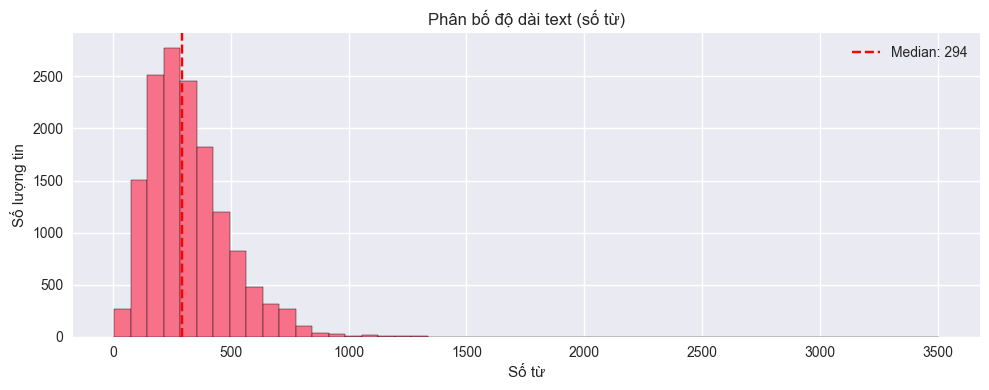


👀 Ví dụ FULL_TEXT:
sale admin website dhc việt nam trực_thuộc công_ty cp belie nhà phân_phối độc_quyền mỹ_phẩm và thực_phẩm chức_năng dhc nhật bản tại việt_nam với sứ_mệnh triết_lý kinh_doanh cung_cấp những sản_phẩm thực và chất với chất_lượng dịch_vụ dẫn_đầu và giá_thành hợp_lý nhất cho người tiêu_dùng việt nam đem l...


In [28]:
# 1.7 Gộp các cột text thành FULL_TEXT

print("🔗 Đang gộp các cột text thành FULL_TEXT...\n")

# Gộp tất cả text columns
df['FULL_TEXT'] = (
    df['Job Title'] + ' ' +
    df['Company Overview'] + ' ' +
    df['Job Description'] + ' ' +
    df['Job Requirements'] + ' ' +
    df['Benefits']
)

# Thống kê
df['text_word_count'] = df['FULL_TEXT'].str.split().str.len()

print(f"✅ Đã tạo cột FULL_TEXT")
print(f"\n📊 Thống kê độ dài text:")
print(df['text_word_count'].describe())

# Visualize distribution
plt.figure(figsize=(10, 4))
plt.hist(df['text_word_count'], bins=50, edgecolor='black')
plt.xlabel('Số từ')
plt.ylabel('Số lượng tin')
plt.title('Phân bố độ dài text (số từ)')
plt.axvline(df['text_word_count'].median(), color='red', linestyle='--', label=f'Median: {df["text_word_count"].median():.0f}')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n👀 Ví dụ FULL_TEXT:")
print(df['FULL_TEXT'].iloc[0][:300] + "...")

In [29]:
# 1.8 Lưu kết quả preprocessing

# Chọn các cột cần thiết cho bước tiếp theo
final_cols = [
    'FULL_TEXT',
    'Job Title',
    'Company Overview',
    'Job Description',
    'Job Requirements',
    'Benefits',
    'Company Size',
    'Years of Experience',
    'Number Cadidate',
    'Salary'
]

df_final = df[final_cols].copy()

# Lưu file
df_final.to_csv(
    "../data/JOB_DATA_LABELLED.csv",
    index=False,
    encoding="utf-8-sig"
)

print("💾 Đã lưu file: data/JOB_DATA_LABELLED.csv")
print(f"📊 Shape: {df_final.shape}")
print(f"\n✅ Checkpoint 1 hoàn thành!\n")

df_final.head()

OSError: Cannot save file into a non-existent directory: '..\data'

### ✅ Checkpoint 1: Hoàn thành Preprocessing

**Đã làm:**
- ✅ Làm sạch văn bản (lowercase, remove special chars)
- ✅ Tách từ tiếng Việt với PyVi
- ✅ Gộp text thành FULL_TEXT
- ✅ Lưu file: `JOB_DATA_LABELLED.csv`

**Tiếp theo:**
- ➡️ Bước 2: Feature Engineering (trích xuất 30+ features)

---

## 🔧 Bước 2: Feature Engineering

### 🎯 Mục tiêu
Tăng từ **5 features cơ bản** → **30+ features chất lượng cao**

### 📊 Nhóm features
1. **Text Features** (10+): độ dài, từ vựng, chữ hoa, scam keywords, positive keywords
2. **Salary Features** (6+): mức lương avg, nghi ngờ cao/thấp, negotiable
3. **Company Features** (5+): quy mô công ty, thông tin công ty
4. **Requirement Features** (6+): kinh nghiệm, số lượng tuyển, yêu cầu

### 💡 Ý tưởng
- **Scam keywords**: "việc nhẹ lương cao", "không cần kinh nghiệm", "thu nhập không giới hạn"
- **Positive keywords**: "bảo hiểm", "hợp đồng", "phụ cấp", "đào tạo"
- **Salary patterns**: Phát hiện lương bất thường cao (>50M) hoặc quá thấp (<3M)